**Import Librarires**

In [2]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/BostonHousing.csv")

**Analyzing Data**

In [3]:
#first five rowa of data
df.head(5)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
#Total NUmber Of rows And column in data
df.shape

(506, 14)

In [5]:
#Checking null values
df.isnull().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


In [6]:
#Analyzing Numerical Features Of data
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [7]:
#Checking Duplicates in data
df.duplicated().sum()

np.int64(0)

In [8]:
#checking correlation between numerical features
df.corr()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


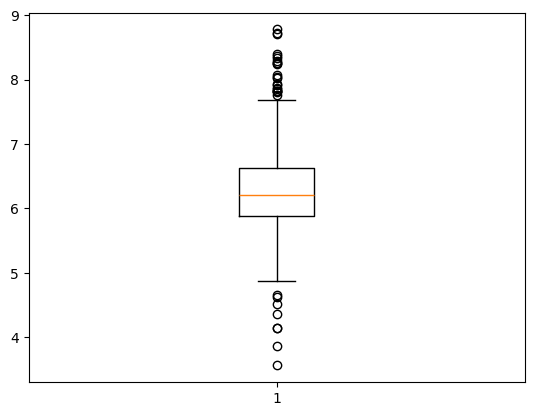

In [9]:
#After correlation table we can see that 'rm' feature and target(medv) is high positivly corelated so we will clean 'rm' column by removing its outliers
import matplotlib.pyplot as plt

plt.boxplot(df["rm"])
plt.show()

In [10]:
#ranging the data
Q1 = df["rm"].quantile(0.25)
Q3 = df["rm"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df["rm"] >= lower) & (df["rm"] <= upper)]

In [11]:
#seperating input and output column
x=df.drop("medv",axis=1)
y=df["medv"]

**Model Training**

In [12]:
#splitting data into train and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [13]:
#performing standadization of data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)   # Learn mean/std from training data
x_test = scaler.transform(x_test)

In [14]:
#applying linear regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
lr=LinearRegression()

In [15]:
lr.fit(x_train,y_train)

LinearRegression()

In [16]:
lr.predict(x_train)
r2_score(y_train,lr.predict(x_train))

0.7091926757646103

In [17]:
y_pred_lr=lr.predict(x_test)
r2_score(y_test,lr.predict(x_test))

0.7761382418907905

In [18]:
#Linear Regression assumes a linear relationship, but many relationships are nonlinear.
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(x_train)
X_test_poly = poly.transform(x_test)

In [19]:
lr.fit(X_train_poly, y_train)

LinearRegression()

In [20]:
lr.predict(X_train_poly)
r2_score(y_train,lr.predict(X_train_poly))

0.9118819142904457

In [21]:
y_pred_poly=lr.predict(X_test_poly)
r2_score(y_test,lr.predict(X_test_poly))

0.8039883593085291

**comparing both model in one figure**

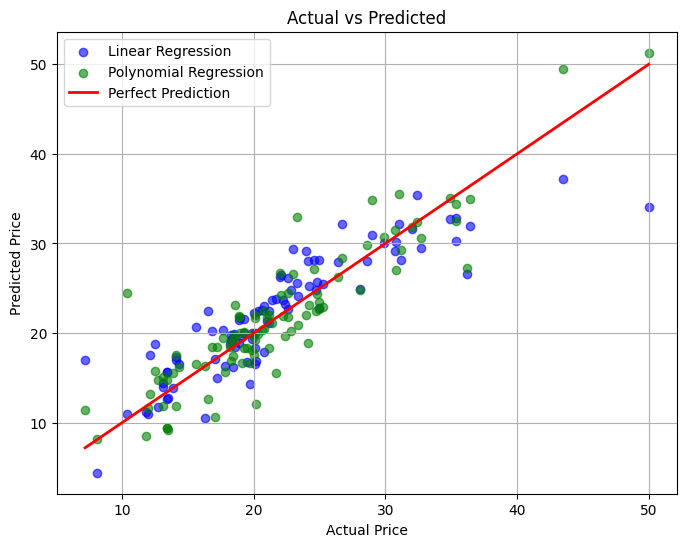

In [22]:
plt.figure(figsize=(8,6))

# Linear Regression
plt.scatter(y_test, y_pred_lr,
            color='blue',
            alpha=0.6,
            label='Linear Regression')

# Polynomial Regression
plt.scatter(y_test, y_pred_poly,
            color='green',
            alpha=0.6,
            label='Polynomial Regression')

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red',
         linewidth=2,
         label='Perfect Prediction')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
import pickle
pickle.dump(lr,open("regmodel.pkl","wb"))
pickled_model=pickle.load(open("regmodel.pkl","rb"))
pickled_model.predict(poly.transform(x_test))

array([18.88983859, 15.14017033, 17.40289698, 20.27668333, 18.34011469,
       16.93955523, 29.83336179, 35.01289754, 34.41011351, 21.83719483,
       12.68871646, 19.97875232, 26.26024054, 22.01902359, 24.37890481,
       19.21989741, 14.80623767, 20.09460718, 10.60606416, 31.89323424,
       24.52721771, 49.49463241, 27.18968837, 13.17040553, 22.05645306,
       51.2903593 , 21.85616456, 22.71919541, 11.66220869, 21.84655659,
       21.73229251, 35.12218655, 14.76326569, 26.54866556, 32.48024463,
       21.94719086, 12.10679679, 19.46215297, 11.81064808, 21.09008986,
       27.06570966,  8.5205501 , 27.2279228 , 18.48066868, 19.92946819,
       17.55165272, 22.46168713, 24.45465228, 15.50569413, 35.46919083,
       19.37320048, 17.53321627, 30.61751279, 18.84943737, 24.76019035,
       30.76030344, 20.92811598,  9.18229769, 16.61669736, 26.67543343,
       15.66968706, 20.47544369, 23.50189622, 34.83603785, 16.57283428,
       18.34531138, 23.17015717, 11.37075872, 18.09389937, 16.21

In [24]:
from google.colab import files

files.download("regmodel.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
import pickle

pickle.dump(scaler, open("scaler.pkl", "wb"))

In [26]:
from google.colab import files

files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
pickle.dump(poly, open("poly.pkl", "wb"))
files.download("poly.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>